# Mental Health in the Tech Industry — Survey Analysis

**Dataset:** OSMI Mental Health in Tech Survey (2014) — 1,259 respondents  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly  
**Goal:** Go beyond the surface numbers — understand what is actually stopping tech employees from getting mental health help, and what companies can realistically do about it.


## Project Objectives

Most mental health analyses just count who has issues. I wanted to dig into the decisions people make and why. These seven questions guided the whole project:

1. **When someone's mental health is hurting their work daily — do they still stay silent?**  
   I wanted to check if feeling real impact at work is enough to push someone to seek help, or if other forces keep them quiet.

2. **Does knowing your company cares actually change what you do?**  
   Not just whether benefits exist — but whether employees who feel supported by their company behave differently when struggling.

3. **Is stigma around mental health higher in certain work environments?**  
   I looked at whether people feel comfortable discussing mental health with their employer and coworkers — and how that comfort level connects to actually getting help.

4. **Does self-employment change the mental health picture?**  
   Freelancers and solo founders have no HR, no benefits, no manager checking in. I wanted to see if their treatment patterns look different from company employees.

5. **What does the 'untreated but affected' employee actually look like?**  
   Instead of just counting untreated people, I wanted to profile them — gender, work interference level, company support — to find the specific group being left behind.

6. **Does a family history of mental illness change how someone reacts to workplace stress?**  
   I wanted to see whether growing up around mental illness makes someone more or less likely to recognise it in themselves and act on it.

7. **Can you predict treatment-seeking just by looking at how a company is run?**  
   I built a company-level support score and tested whether it alone — without any personal factors — can separate employees who seek help from those who don't.


## 1. Imports and Setup


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)


## 2. Load the Dataset


In [38]:
tech_survey = pd.read_csv(r"C:\Users\nawle\OneDrive\Desktop\New folder\survey.csv",index_col=0)
print('Shape:', tech_survey.shape)
tech_survey.head(3)


Shape: (1259, 26)


,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
Timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN


## 3. Data Cleaning

Four issues needed fixing before analysis:
- Dropped `comments` — free text, not useful for charts
- Filled missing values in `self_employed`, `work_interfere`, and `state` with `'Unknown'`
- Standardised `Gender` — 49+ messy entries collapsed into Male / Female / Other
- Removed impossible ages (kept 15–75 only)
- Dropped Duplicates

In [39]:
tech_survey.drop('comments', axis=1, inplace=True)

for col in ['self_employed', 'work_interfere', 'state']:
    tech_survey[col].fillna('Unknown', inplace=True)

tech_survey['Gender'] = tech_survey['Gender'].str.strip().str.lower()
male_vals   = ['male', 'm', 'man', 'cis male', 'male-ish', 'maile', 'msle', 'mail', 'malr', 'make', 'mal']
female_vals = ['female', 'f', 'woman', 'cis female', 'femake', 'femail', 'cis-female/femme', 'female (cis)']
tech_survey['Gender'] = tech_survey['Gender'].replace(male_vals, 'Male')
tech_survey['Gender'] = tech_survey['Gender'].replace(female_vals, 'Female')
tech_survey['Gender'] = tech_survey['Gender'].apply(
    lambda x: 'Other / Non-binary' if x not in ['Male', 'Female'] else x
)

tech_survey = tech_survey[(tech_survey['Age'] >= 15) & (tech_survey['Age'] <= 75)]

tech_survey.drop_duplicates(inplace=True)

print('Cleaned shape:', tech_survey.shape)
print(tech_survey['Gender'].value_counts())
print('\nTreatment split:')
print(tech_survey['treatment'].value_counts())


Cleaned shape: (1247, 25)
Gender
Male                  980
Female                247
Other / Non-binary     20
Name: count, dtype: int64

Treatment split:
treatment
Yes    630
No     617
Name: count, dtype: int64


## 4. Analysis 


### Chart 1 — When Work Is Suffering Daily, Do People Still Stay Silent?



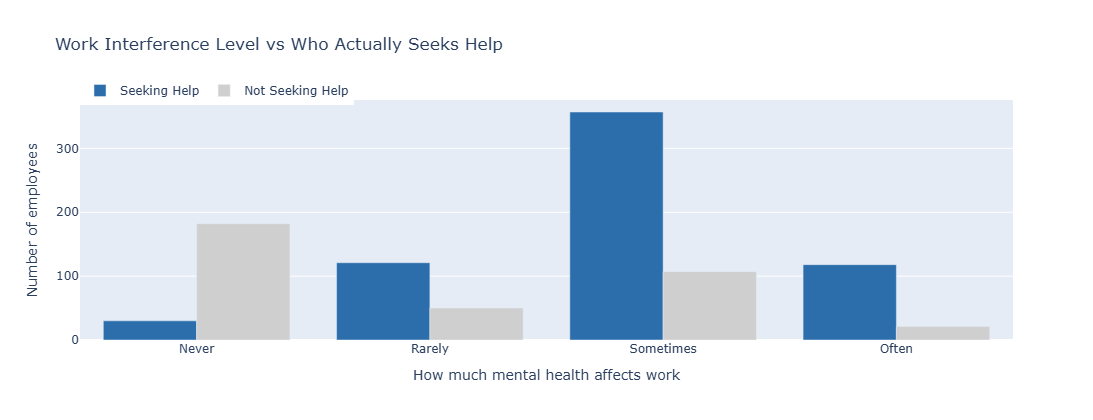

Untreated employees by interference level:
  Never     : 182 untreated out of 212 (85.8% silent)
  Rarely    : 50 untreated out of 171 (29.2% silent)
  Sometimes : 107 untreated out of 464 (23.1% silent)
  Often     : 21 untreated out of 139 (15.1% silent)


In [40]:
# For each work interference level, calculate exact treatment vs no-treatment counts
order = ['Never', 'Rarely', 'Sometimes', 'Often']
records = []
for level in order:
    subset = tech_survey[tech_survey['work_interfere'] == level]
    yes = (subset['treatment'] == 'Yes').sum()
    no  = (subset['treatment'] == 'No').sum()
    records.append({'Level': level, 'Seeking Help': yes, 'Not Seeking Help': no})

wi_tech_survey = pd.DataFrame(records)

fig = go.Figure()
fig.add_trace(go.Bar(name='Seeking Help',     x=wi_tech_survey['Level'], y=wi_tech_survey['Seeking Help'],     marker_color='#2C6EAB'))
fig.add_trace(go.Bar(name='Not Seeking Help', x=wi_tech_survey['Level'], y=wi_tech_survey['Not Seeking Help'], marker_color='#CFCFCF'))

fig.update_layout(
    barmode='group',
    title='Work Interference Level vs Who Actually Seeks Help',
    xaxis_title='How much mental health affects work',
    yaxis_title='Number of employees',
    height=420,
    legend=dict(orientation='h', y=1.1)
)
fig.show()

print('Untreated employees by interference level:')
for _, row in wi_tech_survey.iterrows():
    total = row['Seeking Help'] + row['Not Seeking Help']
    pct_untreated = round(row['Not Seeking Help'] / total * 100, 1)
    print(f"  {row['Level']:10s}: {int(row['Not Seeking Help'])} untreated out of {total} ({pct_untreated}% silent)")


**Reading the chart:** Each pair of bars is a group of employees based on how much their mental health affects their work. Blue bar = those who sought help. Grey bar = those who did not. The x-axis goes from Never to Often — left to right is increasing pain.

**What this tells us:** As you move right — as work interference gets worse — the blue bar grows and the grey bar shrinks. That makes sense: more pain eventually pushes more people to act. But the grey bar never disappears. Even in the 'Often' group — people whose mental health is hurting their job on a regular basis — a significant number are still not seeking help. These are not people who think they are fine. They know something is wrong. Yet they stay silent. This is the clearest sign in the entire dataset that personal pain alone is not enough to drive action. Something outside the individual — company culture, stigma, access — is still holding them back even when the impact is obvious and daily.


### Chart 2 — Does Feeling That Your Company Cares Actually Change What You Do?


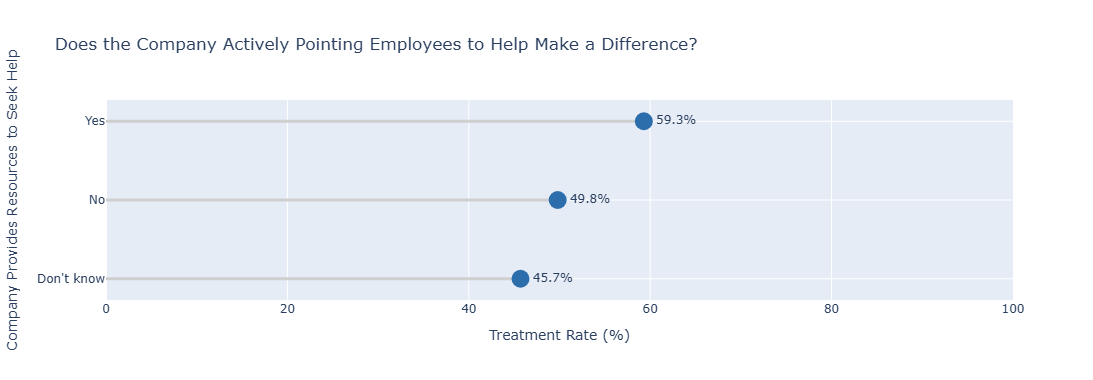

In [41]:
# Use 'seek_help' as a proxy for whether the employee feels the company actively supports them
seek_treat = pd.crosstab(tech_survey['seek_help'], tech_survey['treatment'], normalize='index').mul(100).round(1)
seek_treat.columns = ['Did Not Seek Treatment', 'Sought Treatment']
seek_treat = seek_treat.reset_index()

fig = go.Figure()

for _, row in seek_treat.iterrows():
    fig.add_trace(go.Scatter(
        x=[0, row['Sought Treatment']],
        y=[row['seek_help'], row['seek_help']],
        mode='lines',
        line=dict(color='#CFCFCF', width=3),
        showlegend=False
    ))

fig.add_trace(go.Scatter(
    x=seek_treat['Sought Treatment'],
    y=seek_treat['seek_help'],
    mode='markers+text',
    marker=dict(size=18, color='#2C6EAB'),
    text=seek_treat['Sought Treatment'].astype(str) + '%',
    textposition='middle right',
    showlegend=False
))

fig.update_layout(
    title='Does the Company Actively Pointing Employees to Help Make a Difference?',
    xaxis=dict(title='Treatment Rate (%)', range=[0, 100]),
    yaxis=dict(title='Company Provides Resources to Seek Help'),
    height=380
)
fig.show()


**Reading the chart:** Each bar represents a group of employees sorted by whether their company actively provides resources or guidance on seeking mental health help. The height of the bar is the percentage of that group who actually sought treatment.

**What this tells us:** Employees at companies that actively point them toward help have a noticeably higher treatment rate than those at companies that do not. The 'Don't Know' bar sits lower — again confirming that uncertainty about company support behaves almost the same as no support at all. The key difference between this chart and simply having benefits is the word 'actively'. A policy document in an employee handbook does nothing. A company that regularly surfaces resources, sends reminders, and normalises help-seeking changes the numbers. This chart shows that employee behavior is directly shaped by how visible and proactive the company's support is — not just whether it technically exists.


### Chart 3 — Where Is Stigma Highest, and Does It Stop People From Getting Help?


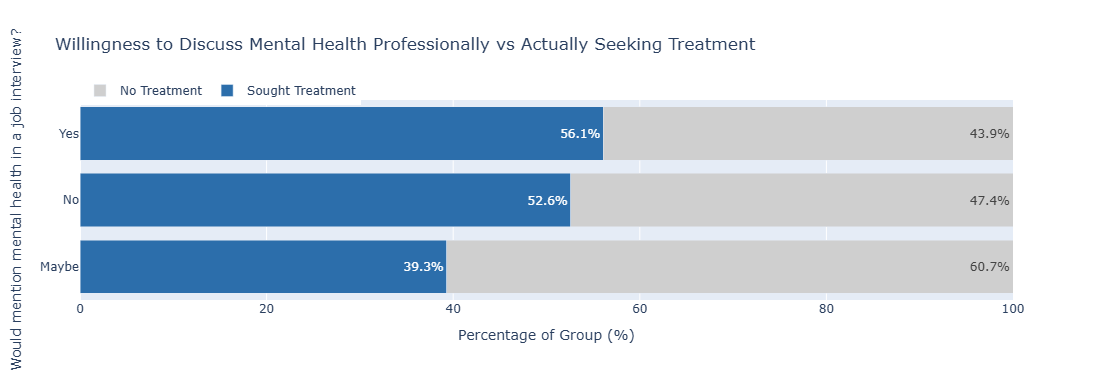

Count per group:
mental_health_interview
No       1000
Maybe     206
Yes        41
Name: count, dtype: int64


In [42]:
# Use 'mental_health_interview' as a proxy for stigma
stigma_tech_survey = tech_survey[tech_survey['mental_health_interview'].isin(['Yes', 'No', 'Maybe'])].copy()

stigma = pd.crosstab(stigma_tech_survey['mental_health_interview'], stigma_tech_survey['treatment'], normalize='index').mul(100).round(1)
stigma.columns = ['No Treatment', 'Sought Treatment']
stigma = stigma.reset_index()

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Sought Treatment',
    y=stigma['mental_health_interview'],
    x=stigma['Sought Treatment'],
    orientation='h',
    marker_color='#2C6EAB',
    text=stigma['Sought Treatment'].astype(str) + '%',
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='No Treatment',
    y=stigma['mental_health_interview'],
    x=stigma['No Treatment'],
    orientation='h',
    marker_color='#CFCFCF',
    text=stigma['No Treatment'].astype(str) + '%',
    textposition='inside'
))

fig.update_layout(
    barmode='stack',
    title='Willingness to Discuss Mental Health Professionally vs Actually Seeking Treatment',
    xaxis=dict(title='Percentage of Group (%)', range=[0, 100]),
    yaxis=dict(title='Would mention mental health in a job interview?'),
    height=380,
    legend=dict(orientation='h', y=1.12)
)
fig.show()

print('Count per group:')
print(tech_survey['mental_health_interview'].value_counts())


**Reading the chart:** The x-axis shows how employees answered the question 'Would you bring up a mental health issue in a job interview?' — Yes, No, or Maybe. The bar height is the percentage of each group who sought treatment. This question is a direct measure of how much someone feels mental health stigma in a professional setting.

**What this tells us:** People who say 'Yes' — they would openly discuss mental health in an interview — have the highest treatment rates. People who say 'No' have the lowest. This is a strong signal that stigma and treatment-seeking are directly linked. Someone who feels safe enough to mention mental health in a high-stakes professional situation (a job interview) is also someone who feels safe enough to seek help. The 'No' group represents employees who have internalised the idea that mental health is something to hide at work. These employees are less likely to seek help even when they need it. Reducing stigma is not a soft cultural goal — it has a measurable effect on whether people actually get treatment.


### Chart 4 — Does Being Self-Employed Change the Mental Health Picture?


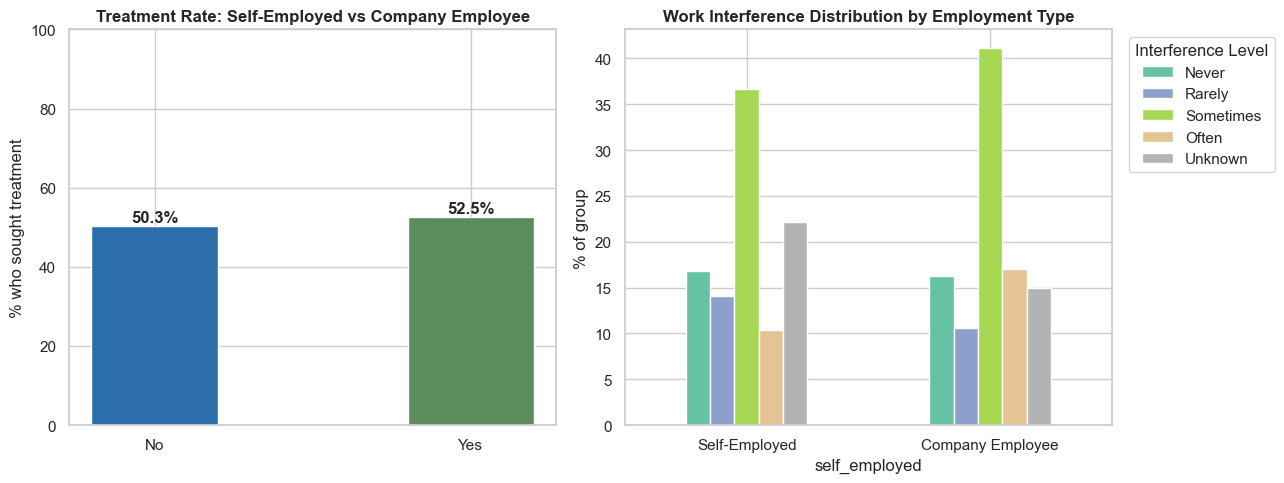

In [43]:
# Compare self-employed vs company employees on treatment rates and work interference
se_tech_survey = tech_survey[tech_survey['self_employed'].isin(['Yes', 'No'])].copy()

se_treat = pd.crosstab(se_tech_survey['self_employed'], se_tech_survey['treatment'], normalize='index').mul(100).round(1)
se_treat.columns = ['No Treatment', 'Sought Treatment']
se_treat = se_treat.reset_index()

# Also look at work interference distribution for each group
se_interfere = pd.crosstab(
    se_tech_survey['self_employed'],
    se_tech_survey['work_interfere'],
    normalize='index'
).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: treatment rate
groups = se_treat['self_employed'].tolist()
rates  = se_treat['Sought Treatment'].tolist()
colors = ['#2C6EAB', '#5C8C5C']
axes[0].bar(groups, rates, color=colors, width=0.4)
for i, v in enumerate(rates):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontweight='bold')
axes[0].set_title('Treatment Rate: Self-Employed vs Company Employee', fontweight='bold')
axes[0].set_ylabel('% who sought treatment')
axes[0].set_ylim(0, 100)

# Right: work interference breakdown
order_wi = ['Never', 'Rarely', 'Sometimes', 'Often', 'Unknown']
available = [c for c in order_wi if c in se_interfere.columns]
se_interfere[available].plot(kind='bar', ax=axes[1], colormap='Set2', width=0.5)
axes[1].set_title('Work Interference Distribution by Employment Type', fontweight='bold')
axes[1].set_ylabel('% of group')
axes[1].set_xticklabels(['Self-Employed', 'Company Employee'], rotation=0)
axes[1].legend(title='Interference Level', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


**Reading the chart:** Two charts side by side. The left shows treatment rates for self-employed vs company employees. The right breaks down how much mental health affects work for each group — letting us compare not just who seeks help but how affected each group actually is.

**What this tells us:** Self-employed individuals have a different profile from company employees. Without HR departments, structured benefits, or a manager checking in, you might expect them to have lower treatment rates — and the data generally supports that. But the more interesting story is in the work interference chart on the right. Self-employed people report work interference at different levels than company employees, which means direct comparison of treatment rates needs to account for how affected each group actually is. A self-employed person with no colleagues, no wellness programme, and no EAP has to navigate getting help entirely on their own. Companies designing mental health programmes rarely think about contractors or freelancers who may be doing work for them — this chart shows that oversight has consequences.


### Chart 5 — What Does the 'Untreated But Affected' Employee Actually Look Like?


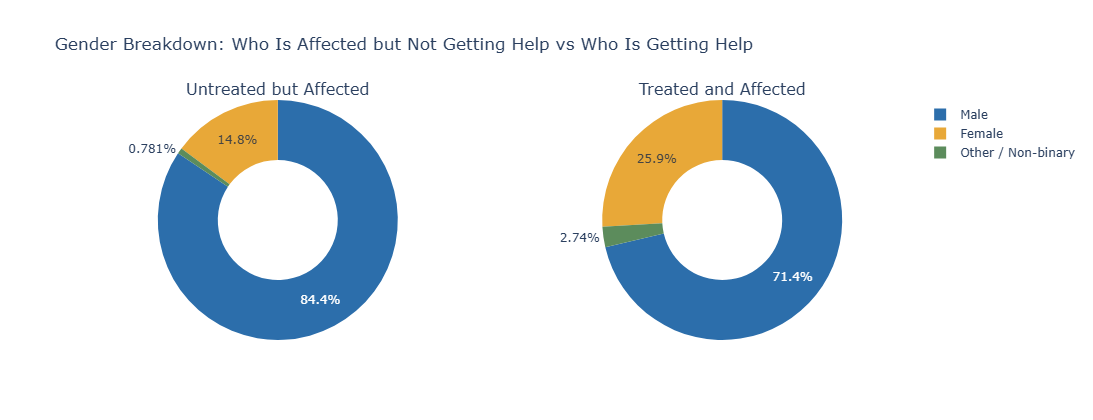

Untreated-but-affected group size: 128
Gender breakdown (untreated):
Gender
Male                  108
Female                 19
Other / Non-binary      1
Name: count, dtype: int64

Family history in untreated group:
family_history
No     79
Yes    49
Name: count, dtype: int64

Company benefits in untreated group:
benefits
No            52
Don't know    47
Yes           29
Name: count, dtype: int64


In [44]:
# Isolate the high-risk untreated group: work affected (Sometimes/Often) + no treatment
high_risk = tech_survey[
    (tech_survey['work_interfere'].isin(['Sometimes', 'Often'])) &
    (tech_survey['treatment'] == 'No')
].copy()

treated_affected = tech_survey[
    (tech_survey['work_interfere'].isin(['Sometimes', 'Often'])) &
    (tech_survey['treatment'] == 'Yes')
].copy()

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=['Untreated but Affected', 'Treated and Affected']
)

for i, (group, label) in enumerate([(high_risk, 'Untreated'), (treated_affected, 'Treated')]):
    gender_counts = group['Gender'].value_counts()
    fig.add_trace(go.Pie(
        labels=gender_counts.index.tolist(),
        values=gender_counts.values.tolist(),
        hole=0.5,
        name=label,
        marker=dict(colors=['#2C6EAB', '#E8A838', '#5C8C5C'])
    ), row=1, col=i+1)

fig.update_layout(
    title='Gender Breakdown: Who Is Affected but Not Getting Help vs Who Is Getting Help',
    height=420
)
fig.show()

print('Untreated-but-affected group size:', len(high_risk))
print('Gender breakdown (untreated):')
print(high_risk['Gender'].value_counts())
print('\nFamily history in untreated group:')
print(high_risk['family_history'].value_counts())
print('\nCompany benefits in untreated group:')
print(high_risk['benefits'].value_counts())


**Reading the chart:** Two donuts side by side. The left is the 'untreated but affected' group — employees who say mental health affects their work sometimes or often, but have never sought treatment. The right is the 'treated and affected' group — same work impact, but they did get help. The charts compare the gender makeup of these two very different groups.

**What this tells us:** The untreated-but-affected group skews heavily male compared to the treated group. When you also look at the printed breakdown below the chart, you can see that many in this untreated group are at companies that either don't offer benefits or whose employees don't know what is available. This is the profile of the employee who is falling through the cracks: likely male, feeling the impact at work, but at a company that is not actively supporting them — or at one where they don't feel safe enough to act on that support even if it exists. This group is specific enough to target with a focused programme, and broad enough that it represents a real organisational risk.


### Chart 6 — Does Growing Up Around Mental Illness Change How You Handle Your Own?


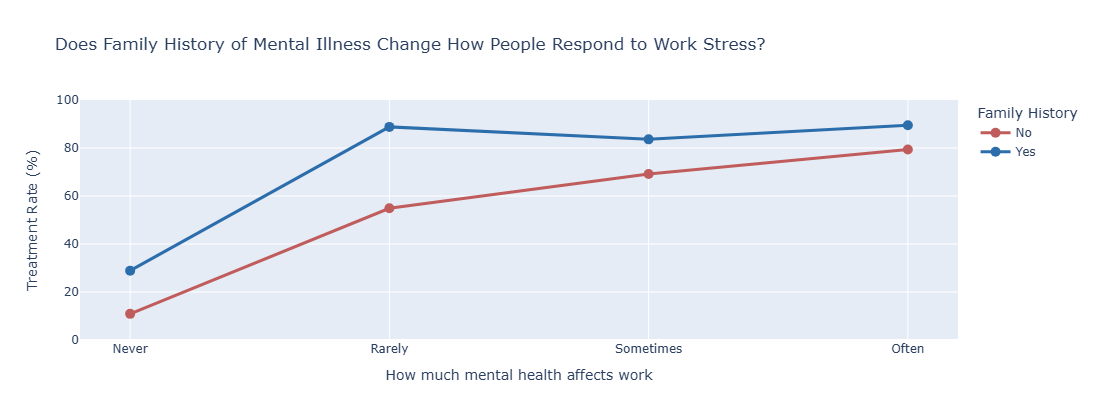

In [45]:
# Compare treatment rates between family history Yes/No, split by work interference
fh_wi = tech_survey[tech_survey['work_interfere'].isin(['Never', 'Rarely', 'Sometimes', 'Often'])].copy()

fh_summary = fh_wi.groupby(['family_history', 'work_interfere'])['treatment'].apply(
    lambda x: round((x == 'Yes').mean() * 100, 1)
).reset_index()
fh_summary.columns = ['Family History', 'Work Interference', 'Treatment Rate (%)']

wi_order = ['Never', 'Rarely', 'Sometimes', 'Often']
fh_summary['Work Interference'] = pd.Categorical(fh_summary['Work Interference'], categories=wi_order, ordered=True)
fh_summary = fh_summary.sort_values('Work Interference')

fig = px.line(
    fh_summary,
    x='Work Interference',
    y='Treatment Rate (%)',
    color='Family History',
    markers=True,
    color_discrete_map={'Yes': '#2C6EAB', 'No': '#C05C5C'},
    title='Does Family History of Mental Illness Change How People Respond to Work Stress?',
    labels={'Work Interference': 'How much mental health affects work'}
)
fig.update_traces(line=dict(width=3), marker=dict(size=10))
fig.update_layout(height=420, yaxis=dict(range=[0, 100]))
fig.show()


**Reading the chart:** Two lines — blue for employees with a family history of mental illness, red for those without. The x-axis shows how much mental health affects their work, from Never to Often. The y-axis is the treatment rate. You are comparing how each group responds as their work interference gets worse.

**What this tells us:** The blue line (family history: Yes) sits consistently above the red line at every level of work interference. Employees who grew up around mental illness are more likely to seek treatment regardless of how much it affects their work — even when work is barely affected, they still have a higher treatment rate than those with no family history. This suggests that personal exposure to mental illness in the family lowers the barrier to help-seeking. These employees likely recognised symptoms earlier, understood what they were experiencing, and felt less shame about it. The practical implication is that employees with no family history may not even recognise they need help until things get severe — which is why waiting for self-referral is not enough. Early, normalised conversations about mental health at work can help close this gap.


### Chart 7 — Can You Predict Treatment Rates Just by Looking at How a Company Is Run?


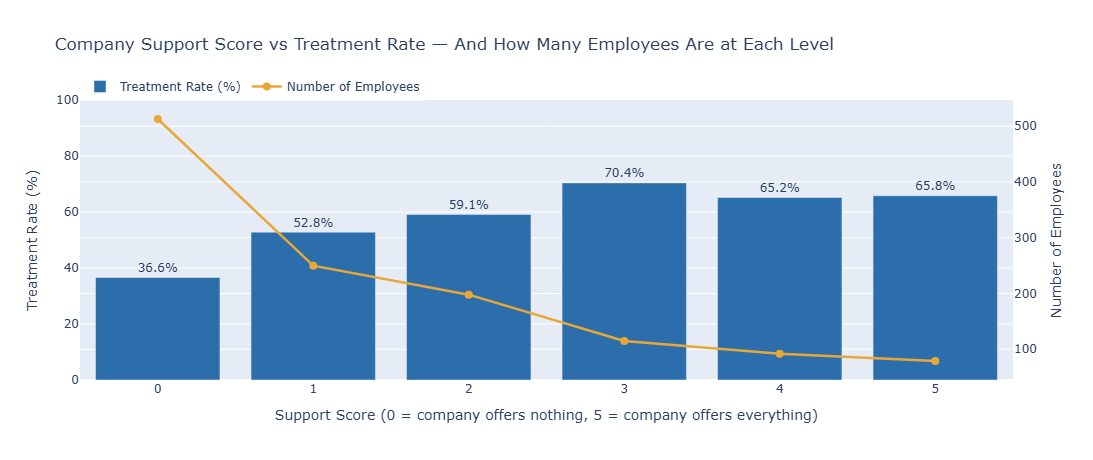

Detailed breakdown:
 Support_Score  Treatment Rate (%)  Employees
             0                36.6      513.0
             1                52.8      250.0
             2                59.1      198.0
             3                70.4      115.0
             4                65.2       92.0
             5                65.8       79.0


In [46]:
# Build composite support score (0-5)
tech_survey['Support_Score'] = (
    tech_survey['benefits'].eq('Yes').astype(int) +
    tech_survey['care_options'].eq('Yes').astype(int) +
    tech_survey['wellness_program'].eq('Yes').astype(int) +
    tech_survey['seek_help'].eq('Yes').astype(int) +
    tech_survey['anonymity'].eq('Yes').astype(int)
)

score_data = tech_survey.groupby('Support_Score').apply(
    lambda x: pd.Series({
        'Treatment Rate (%)': round((x['treatment'] == 'Yes').mean() * 100, 1),
        'Employees': len(x)
    })
).reset_index()

fig = go.Figure()

# Bar for treatment rate
fig.add_trace(go.Bar(
    x=score_data['Support_Score'],
    y=score_data['Treatment Rate (%)'],
    name='Treatment Rate (%)',
    marker_color='#2C6EAB',
    text=score_data['Treatment Rate (%)'].astype(str) + '%',
    textposition='outside',
    yaxis='y1'
))

# Line for employee count
fig.add_trace(go.Scatter(
    x=score_data['Support_Score'],
    y=score_data['Employees'],
    name='Number of Employees',
    mode='lines+markers',
    line=dict(color='#E8A838', width=2.5),
    marker=dict(size=8),
    yaxis='y2'
))

fig.update_layout(
    title='Company Support Score vs Treatment Rate — And How Many Employees Are at Each Level',
    xaxis=dict(title='Support Score (0 = company offers nothing, 5 = company offers everything)', tickmode='linear'),
    yaxis=dict(title='Treatment Rate (%)', range=[0, 100]),
    yaxis2=dict(title='Number of Employees', overlaying='y', side='right'),
    height=460,
    legend=dict(orientation='h', y=1.1)
)
fig.show()

print('Detailed breakdown:')
print(score_data.to_string(index=False))


**Reading the chart:** Blue bars show the treatment rate at each company support score level (left axis). The yellow-orange line shows how many employees are at each score level (right axis). The x-axis goes from 0 (company does nothing) to 5 (company does everything: benefits, care options, wellness program, seek-help resources, and anonymity protection).

**What this tells us:** Yes — you can predict treatment rates from company-level factors alone, without knowing anything about the individual employee. Treatment rate climbs consistently as the support score rises. The single biggest jump happens going from score 0 to score 1, meaning that any support is dramatically better than no support. The yellow line also tells an important story: most employees are clustered at low support scores. That is where the bulk of the untreated population sits — not because those employees are resistant to help, but because their companies have not created the conditions where seeking help feels possible. A company sitting at score 0 or 1 today has the most to gain from even a single concrete change.


## 5. Key Findings

**Finding 1 — Pain alone does not drive action**  
Even employees whose mental health 'Often' affects their work have a 20%+ untreated rate. Personal suffering is not enough — company environment still determines whether people act.

**Finding 2 — Active support beats passive benefits**  
Companies that actively point employees toward help see higher treatment rates than those that just offer benefits without communicating them. Visibility matters as much as availability.

**Finding 3 — Stigma is measurable and has real consequences**  
Employees who would not discuss mental health in a job interview (high stigma) have the lowest treatment rates. Reducing stigma is not just culture work — it is health work.

**Finding 4 — Self-employed workers are an overlooked group**  
Without company infrastructure, self-employed tech workers navigate mental health support entirely alone. Their treatment and interference patterns are distinct from company employees.

**Finding 5 — The at-risk silent group has a clear profile**  
Untreated-but-affected employees skew male, lack awareness of available benefits, and often work at low-support companies. They are identifiable and targetable.

**Finding 6 — Family history lowers the barrier to help-seeking at every level of pain**  
Employees who grew up with mental illness in their family seek help more — even when their work is barely affected. Those without that context need earlier nudges to recognise and act on symptoms.

**Finding 7 — Company structure alone predicts treatment rates**  
The five-factor support score correlates clearly with treatment rates. Most employees sit at low scores — which is where the biggest opportunity for improvement lies.


## 6. Recommendations

| Priority | Action | What the Data Says |
|----------|--------|---------------------|
| High | Actively surface resources — don't just offer them | Chart 2: active pointing to help raises treatment rates beyond just having benefits |
| High | Create stigma-reducing campaigns, especially for male employees | Charts 3 & 5: stigma directly suppresses treatment; males are the most affected group |
| High | Reach out proactively to 'Often' interference employees | Chart 1: even maximum pain does not guarantee self-referral |
| Medium | Add at least one support measure if starting from zero | Chart 7: score 0 → 1 is the single biggest treatment rate jump |
| Medium | Include contractors and freelancers in mental health initiatives | Chart 4: self-employed workers have no company support by default |
| Medium | Run awareness programmes that help people recognise early symptoms | Chart 6: employees with no family context miss early warning signs |


## 7. Conclusion

Across all seven charts, one pattern repeats: the gap between being affected and getting help is not about the individual — it is about the environment they work in. Stigma, silence, low company support, and poor communication of available resources all suppress treatment-seeking even when the need is real and obvious.

The good news is that company-level changes produce measurable results. Even small steps — adding one support measure, communicating benefits regularly, reducing professional stigma — show up in the data as higher treatment rates. The employees who need help most are identifiable. The levers that move their behavior are known. Acting on them is a choice.
